In [10]:
import cv2
import matplotlib.pyplot as plt  #使用Matplotlib 的 pyplot 模块 进行绘图和显示，所以也可以叫 “pyplot 方式”(通常称为"plt方式")  (也可写为import matplotlib.pyplot as mss, 语法上完全合法, as后面可以是任何有效的python标识符(字母, 数字, 下划线, 不能以数字开头), 但强烈建议使用plt, 因为 plt 是 Matplotlib 社区的标准别名，几乎所有文档、示例、教程都采用这个约定。使用非标准别名会让代码难以被他人理解，也容易与自定义变量混淆。除非有特殊理由（如避免命名冲突），否则应遵循惯例，使用 import matplotlib.pyplot as plt)

In [11]:
# 打开视频文件, 打开视频需要借助 OpenCV 的 VideoCapture(), 这里实例化了一个 cv2.VideoCapture 对象, 并将该对象赋值给变量 video
video = cv2.VideoCapture(r"D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\sample.mp4")
# 读取一帧, 用所创建 cv2.VideoCapture 类型的对象 video 的 read() 方法就可以读取视频中的一帧
# read()方法会有两个返回值, ret 和 frame, 其中 ret 即 return, 用于告知当前是否读到了, 若 ret=1, 即读到了, 为 True, 否则为 False.  frame 就是具体的那一帧
ret, frame = video.read()

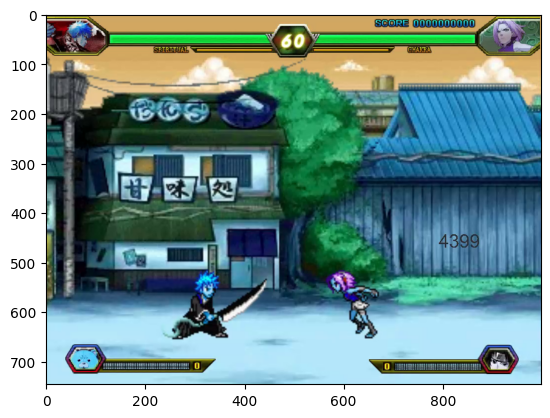

In [12]:
# 接下来通过 matplotlib 的 pyplot 方法()来让它可视化一下
plt.imshow(frame)  # 先前声明了 plt 是 matplotlib.pyplot 方法的别名

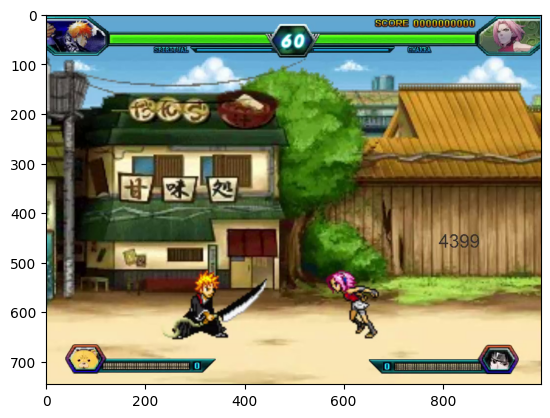

In [13]:
# 但此时也有和上一节讲的一样的问题 (见"D:\Tech\Code\Program\yolov8\ultralytics-main\program\jupyter\predict.ipynb")
# 即这里输出的这一帧 frame 为 BGR, 而不是 plt 所期望的 RGB 的三通道顺序, 故所得到的图颜色不正常
# 上一节是通过[:,:,::-1]这种方式来翻转通道的, 这里我们可以通过 OpenCV 的 cvtcolor() 方式, 来实现由 BGR 到 RGB 的转换, 其中 cv2.cvtcolor(图片, 模式), 图片选中之前的 frame 帧, 模式选为 cv2.COLOR_BGR2RGB 将图像的颜色空间从 BGR 转换为 RGB
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [14]:
# 下面我们看下具体完整怎么写, 即如何将视频导出为一系列帧(图片), 其实只需要一个 while True: 的循环, 里面加一个判断就可以了
video = cv2.VideoCapture(r"D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\sample.mp4")  # # 打开视频文件, 打开视频需要借助 OpenCV 的 VideoCapture(), 这里实例化了一个 cv2.VideoCapture 对象, 并将该对象赋值给变量 video
num = 0  # 计数器
save_step = 30  # 间隔帧, 多少帧存一次, 因为若不考虑多少帧存一次, 就可能导致存下的图片过多
while True:  # while True: 循环
    ret, frame = video.read()   # 读取一帧, 用所创建 cv2.VideoCapture 类型的对象 video 的 read() 方法就可以读取视频中的一帧, read()方法会有两个返回值, ret 和 frame, 其中 ret 即 return, 用于告知当前是否读到了, 若 ret=1, 即读到了, 为 True, 否则为 False.  frame 就是具体的那一帧
    if not ret:  # 等价于 if ret == False, 这里是指当它检测到 ret = 0, 即视频已经结束了, 就退出循环
        break
    num += 1
    if num % save_step == 0:  
        cv2.imwrite("./demo_images/" + str(num) + ".jpg", frame)  # 通过 imwrite 将图片保存到本地 "./demo_images/" (一个当前目录下名为demo_images的文件夹), 需要注意的是确保目录 "./demo_images/" 存在(即当前目录下名为demo_images的文件夹存在), 否则 imwrite 会失败 (不会自动创建目录), +str(num) 将整数转为字符串并拼接, +".jpg" 固定扩展名, frame 为 read() 读取到的帧

# 上述若为 "./demo_images" 则会直接保存到当前目录下, 而不考虑是否应打开 demo_images 文件夹, 因为没有第二个 / (即demo_images后的/), 则没有打开该文件夹
# 故应写为 "./demo_images/"
# 打开当前目录下的demo_images文件夹, 就可以发现它把图片都存下来了
    